In [22]:
import corner
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib
from gwpy.timeseries import TimeSeries
import math
import bilby
from bilby.gw.conversion import generate_all_bbh_parameters
from bilby.core import utils
import numpy as np
from gwosc import datasets
import h5py
import pesummary
from pesummary.io import read
from pesummary.core.plots.plot import _make_comparison_corner_plot
import seaborn as sns
import pandas as pd
import itertools
import argparse
import warnings
import os
import json
import configparser
import errno

plt.style.use('~/research/my_plot_style.style')

def calculate_resolvability_of_complex_frequencies_bilby(json_file_path, percentiles=[16, 84]):
    data = read(json_file_path, package='core')
    posterior_samples = data.samples_dict.to_pandas()
    injection_parameters_dict = data.injection_parameters

    if 'delta_f' in posterior_samples.columns:
        posterior_samples['f2'] = posterior_samples['f1'] + posterior_samples['delta_f']
        injection_parameters_dict['f2'] = injection_parameters_dict['f1'] + injection_parameters_dict['delta_f']
    if 'delta_tau' in posterior_samples.columns:
        posterior_samples['tau2'] = posterior_samples['tau1'] + posterior_samples['delta_tau']
        injection_parameters_dict['tau2'] = injection_parameters_dict['tau1'] + injection_parameters_dict['delta_tau']
    
    f1_samples = posterior_samples['f1']
    f2_samples = posterior_samples['f2']
    tau1_samples = posterior_samples['tau1']
    tau2_samples = posterior_samples['tau2']
    f1_inj = injection_parameters_dict['f1']
    f2_inj = injection_parameters_dict['f2']
    tau1_inj = injection_parameters_dict['tau1']
    tau2_inj = injection_parameters_dict['tau2']

    w1 = 2 * np.pi * f1_inj + 1j / tau1_inj
    w2 = 2 * np.pi * f2_inj + 1j / tau2_inj
    delta_w = w1 - w2
    dw_over_w1 = np.abs(delta_w) / np.abs(w1)

    if not f1_inj == f2_inj:
        sigma_f1 = np.percentile(f1_samples, percentiles[1]) - np.percentile(f1_samples, percentiles[0])
        sigma_f2 = np.percentile(f2_samples, percentiles[1]) - np.percentile(f2_samples, percentiles[0])
        delta_f = np.abs(f1_inj - f2_inj)
        resolvability_f = np.max([sigma_f1, sigma_f2]) / delta_f
    else:
        resolvability_f = None

    if not tau1_inj == tau2_inj:
        sigma_tau1 = np.percentile(tau1_samples, percentiles[1]) - np.percentile(tau1_samples, percentiles[0])
        sigma_tau2 = np.percentile(tau2_samples, percentiles[1]) - np.percentile(tau2_samples, percentiles[0])
        delta_tau = np.abs(tau1_inj - tau2_inj)
        resolvability_tau = np.max([sigma_tau1, sigma_tau2]) / delta_tau
    else:
        resolvability_tau = None

    print('-------------------------')
    print(f"|dw/w1|: {dw_over_w1}")
    print(f"Resolvability in frequency: {resolvability_f}")
    print(f"Resolvability in time: {resolvability_tau}")

    fractional_accuracy_f1 = np.abs(np.percentile(f1_samples, 50) - f1_inj) / np.abs(f1_inj)
    fractional_accuracy_f2 = np.abs(np.percentile(f2_samples, 50) - f2_inj) / np.abs(f2_inj)
    fractional_accuracy_tau1 = np.abs(np.percentile(tau1_samples, 50) - tau1_inj) / np.abs(tau1_inj)
    fractional_accuracy_tau2 = np.abs(np.percentile(tau2_samples, 50) - tau2_inj) / np.abs(tau2_inj)
    print(f"Fractional accuracy in f1: {fractional_accuracy_f1}")
    print(f"Fractional accuracy in f2: {fractional_accuracy_f2}")
    print(f"Fractional accuracy in tau1: {fractional_accuracy_tau1}")
    print(f"Fractional accuracy in tau2: {fractional_accuracy_tau2}")

    dw_samples = 2 * np.pi * (f2_samples - f1_samples) + 1j * (1 / tau2_samples - 1 / tau1_samples)
    dw_inj = 2 * np.pi * (f2_inj - f1_inj) + 1j * (1 / tau2_inj - 1 / tau1_inj)
    fractional_accuracy_dw = np.abs(np.percentile(np.abs(dw_samples), 50) - np.abs(dw_inj)) / np.abs(dw_inj)
    print(f"Fractional accuracy in dw: {fractional_accuracy_dw}")
    print('-------------------------')

    result_dict = {
        'dw_over_w1': dw_over_w1,
        'resolvability_f': resolvability_f,
        'resolvability_tau': resolvability_tau,
        'fractional_accuracy_f1': fractional_accuracy_f1,
        'fractional_accuracy_f2': fractional_accuracy_f2,
        'fractional_accuracy_tau1': fractional_accuracy_tau1,
        'fractional_accuracy_tau2': fractional_accuracy_tau2,
        'fractional_accuracy_dw': fractional_accuracy_dw
    }
    return result_dict

def calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample, path_config, percentiles=[16, 84]):
    """load posterior sample"""
    posterior_samples = pd.read_csv(path_posterior_sample, sep='\s+')
    if '#' in posterior_samples.columns:
        if posterior_samples.iloc[:, -1].isna().all():
            real_columns = posterior_samples.columns[1:].tolist()
            posterior_samples = posterior_samples.iloc[:, :-1]
            posterior_samples.columns = change_param_name(real_columns)
    print(f'\nposterior samples columns: {posterior_samples.columns}')

    """load calculated Evidence"""
    path_Evidence = path_posterior_sample.replace('posterior.dat', 'Evidence.txt')
    Evidence_df = pd.read_csv(path_Evidence, sep='\s+')
    lnB = Evidence_df['lnB'].values[0]

    """load injection parameters"""
    config_ini = configparser.ConfigParser()
    config_ini.optionxform = str
    config_ini.read(path_config, encoding='utf-8')
    if not os.path.exists(path_config):
        raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), path_config)
    config_injection = config_ini['Injection']
    injection_parameters_dict = {}
    injection_param_key_new = change_param_name(config_injection.keys())
    for key, val in zip(injection_param_key_new, config_injection.values()):
        injection_parameters_dict[key] = float(val)
    print(f'\ninjection_parameters_dict: {injection_parameters_dict}')

    if 'delta_f' in posterior_samples.columns:
        posterior_samples['f2'] = posterior_samples['f1'] + posterior_samples['delta_f']
        injection_parameters_dict['f2'] = injection_parameters_dict['f1'] + injection_parameters_dict['delta_f']
    if 'delta_tau' in posterior_samples.columns:
        posterior_samples['tau2'] = posterior_samples['tau1'] + posterior_samples['delta_tau']
        injection_parameters_dict['tau2'] = injection_parameters_dict['tau1'] + injection_parameters_dict['delta_tau']
    
    f1_samples = posterior_samples['f1'] if 'EPparam' not in path_config else 1
    f2_samples = posterior_samples['f2'] if 'EPparam' not in path_config else 1
    tau1_samples = posterior_samples['tau1'] if 'EPparam' not in path_config else 1
    tau2_samples = posterior_samples['tau2'] if 'EPparam' not in path_config else 1
    f1_inj = injection_parameters_dict['f1']
    f2_inj = injection_parameters_dict['f2']
    tau1_inj = injection_parameters_dict['tau1']
    tau2_inj = injection_parameters_dict['tau2']

    w1 = 2 * np.pi * f1_inj + 1j / tau1_inj
    w2 = 2 * np.pi * f2_inj + 1j / tau2_inj
    delta_w = w1 - w2
    dw_over_w1 = np.abs(delta_w) / np.abs(w1)

    if not f1_inj == f2_inj:
        sigma_f1 = np.percentile(f1_samples, percentiles[1]) - np.percentile(f1_samples, percentiles[0])
        sigma_f2 = np.percentile(f2_samples, percentiles[1]) - np.percentile(f2_samples, percentiles[0])
        delta_f = np.abs(f1_inj - f2_inj)
        sigma_f = np.max([sigma_f1, sigma_f2])
        sigma_f_over_f = sigma_f / [f1_inj, f2_inj][np.argmax([sigma_f1, sigma_f2])]
        resolvability_f = sigma_f / delta_f
    else:
        sigma_f = None
        resolvability_f = None

    if not tau1_inj == tau2_inj:
        sigma_tau1 = np.percentile(tau1_samples, percentiles[1]) - np.percentile(tau1_samples, percentiles[0])
        sigma_tau2 = np.percentile(tau2_samples, percentiles[1]) - np.percentile(tau2_samples, percentiles[0])
        delta_tau = np.abs(tau1_inj - tau2_inj)
        sigma_tau = np.max([sigma_tau1, sigma_tau2])
        sigma_tau_over_tau = sigma_tau / [tau1_inj, tau2_inj][np.argmax([sigma_tau1, sigma_tau2])]
        resolvability_tau = sigma_tau / delta_tau
    else:
        sigma_tau = None
        resolvability_tau = None

    print(f'\n{path_posterior_sample} results:')
    print('-------------------------')
    print(f"|dw/w1|: {dw_over_w1}")
    print(f"sigma_f: {sigma_f}")
    print(f"sigma_tau: {sigma_tau}")
    print(f"Resolvability in frequency: {resolvability_f}")
    print(f"Resolvability in time: {resolvability_tau}")

    fractional_accuracy_f1 = np.abs(np.percentile(f1_samples, 50) - f1_inj) / np.abs(f1_inj)
    fractional_accuracy_f2 = np.abs(np.percentile(f2_samples, 50) - f2_inj) / np.abs(f2_inj)
    fractional_accuracy_tau1 = np.abs(np.percentile(tau1_samples, 50) - tau1_inj) / np.abs(tau1_inj)
    fractional_accuracy_tau2 = np.abs(np.percentile(tau2_samples, 50) - tau2_inj) / np.abs(tau2_inj)
    print(f"Fractional accuracy in f1: {fractional_accuracy_f1}")
    print(f"Fractional accuracy in f2: {fractional_accuracy_f2}")
    print(f"Fractional accuracy in tau1: {fractional_accuracy_tau1}")
    print(f"Fractional accuracy in tau2: {fractional_accuracy_tau2}")

    dw_samples = 2 * np.pi * (f2_samples - f1_samples) + 1j * (1 / tau2_samples - 1 / tau1_samples)
    dw_inj = 2 * np.pi * (f2_inj - f1_inj) + 1j * (1 / tau2_inj - 1 / tau1_inj)
    fractional_accuracy_dw = np.abs(np.percentile(np.abs(dw_samples), 50) - np.abs(dw_inj)) / np.abs(dw_inj)
    print(f"Fractional accuracy in dw: {fractional_accuracy_dw}")

    Q1 = np.pi * f1_inj * tau1_inj
    Q2 = np.pi * f2_inj * tau2_inj
    Q_fractional_difference = np.abs(Q1 - Q2) / Q1
    print(f"Q1: {Q1}")
    print(f"Q2: {Q2}")
    print(f"Fractional difference in Q: {Q_fractional_difference}")
    print('-------------------------')

    result_dict = {
        'dw_over_w1': dw_over_w1,
        'sigma_f_over_f': sigma_f_over_f if sigma_f is not None else None,
        'sigma_tau_over_tau': sigma_tau_over_tau if sigma_tau is not None else None,
        'resolvability_f': resolvability_f,
        'resolvability_tau': resolvability_tau,
        'fractional_accuracy_f1': fractional_accuracy_f1,
        'fractional_accuracy_f2': fractional_accuracy_f2,
        'fractional_accuracy_tau1': fractional_accuracy_tau1,
        'fractional_accuracy_tau2': fractional_accuracy_tau2,
        'fractional_accuracy_dw': fractional_accuracy_dw,
        'Q1': Q1,
        'Q2': Q2,
        'Q_fractional_difference': Q_fractional_difference,
        'lnB': lnB
    }
    return result_dict

def change_param_name(param_name_list):
    return_list = []
    for param_name in param_name_list:
        if '_t_0' in param_name:
            param = param_name.replace('_t_0', '1')
        elif '_t_1' in param_name:
            param = param_name.replace('_t_1', '2')
        else:
            param = param_name
        return_list.append(param)
    return return_list

In [26]:
DS_label_list = [
                'pyring_shiftRe_to_220_dw0.3w1_snr100_DSparam',
                'pyring_shiftRe_to_220_dw0.1w1_snr100_DSparam',
                'pyring_shiftRe_to_220_dw0.01w1_snr100_DSparam',
                'pyring_shiftRe_to_220_dw0.001w1_snr100_DSparam',
                'pyring_shiftIm_to_220_dw0.3w1_snr100_DSparam',
                'pyring_shiftIm_to_220_dw0.1w1_snr100_DSparam',
                'pyring_shiftIm_to_220_dw0.01w1_snr100_DSparam',
                'pyring_shiftIm_to_220_dw0.001w1_snr100_DSparam',
                ]

OT_label_list = [
                'pyring_shiftRe_to_220_dw0.3w1_snr100_OTparam',
                'pyring_shiftRe_to_220_dw0.1w1_snr100_OTparam',
                'pyring_shiftRe_to_220_dw0.01w1_snr100_OTparam',
                'pyring_shiftRe_to_220_dw0.001w1_snr100_OTparam',
                'pyring_shiftIm_to_220_dw0.3w1_snr100_OTparam',
                'pyring_shiftIm_to_220_dw0.1w1_snr100_OTparam',
                'pyring_shiftIm_to_220_dw0.01w1_snr100_OTparam',
                'pyring_shiftIm_to_220_dw0.001w1_snr100_OTparam',
                ]

EP_label_list = [
                'pyring_shiftRe_to_220_dw0.3w1_snr100_EPparam',
                'pyring_shiftRe_to_220_dw0.1w1_snr100_EPparam',
                'pyring_shiftRe_to_220_dw0.01w1_snr100_EPparam',
                'pyring_shiftRe_to_220_dw0.001w1_snr100_EPparam',
                'pyring_shiftIm_to_220_dw0.3w1_snr100_EPparam',
                'pyring_shiftIm_to_220_dw0.1w1_snr100_EPparam',
                'pyring_shiftIm_to_220_dw0.01w1_snr100_EPparam',
                'pyring_shiftIm_to_220_dw0.001w1_snr100_EPparam',
                ] 

DS45deg_label_list = [
                'pyring_shift45deg_to_220_dw0.1w1_snr100_DSparam',
                'pyring_shift45deg_to_220_dw0.01w1_snr100_DSparam',
                'pyring_shift45deg_to_220_dw0.001w1_snr100_DSparam'
                ]

OT_45deg_label_list = [
                'pyring_shift45deg_to_220_dw0.1w1_snr100_OTparam',
                'pyring_shift45deg_to_220_dw0.01w1_snr100_OTparam',
                'pyring_shift45deg_to_220_dw0.001w1_snr100_OTparam'
                ]

EP_45deg_label_list = [
                'pyring_shift45deg_to_220_dw0.1w1_snr100_EPparam',
                'pyring_shift45deg_to_220_dw0.01w1_snr100_EPparam',
                'pyring_shift45deg_to_220_dw0.001w1_snr100_EPparam',
                ]

DS_220_221_label_list = [
                'pyring_220_221_snr100_DSparam',
                ]
OT_220_221_label_list = [
                'pyring_220_221_snr100_OTparam'
                ]
EP_220_221_label_list = [
                'pyring_220_221_snr100_EPparam'
                ]

DS_kerr_225_226_label_list = [
                'pyring_a0.9_225_226_snr100_DSparam',
                ]
OT_kerr_225_226_label_list = [
                'pyring_a0.9_225_226_snr100_OTparam'
                ]
EP_kerr_225_226_label_list = [
                'pyring_a0.9_225_226_snr100_EPparam'
                ]

DS_result_list_pyring = []
OT_result_list_pyring = []
EP_result_list_pyring = []
DS_45deg_result_list_pyring = []
OT_45deg_result_list_pyring = []
EP_45deg_result_list_pyring = []
DS_220_221_result_list_pyring = []
OT_220_221_result_list_pyring = []
EP_220_221_result_list_pyring = []
DS_kerr_225_226_result_list_pyring = []
OT_kerr_225_226_result_list_pyring = []
EP_kerr_225_226_result_list_pyring = []

for label in DS_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    DS_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in OT_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    OT_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in EP_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    EP_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in DS45deg_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    DS_45deg_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in OT_45deg_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    OT_45deg_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in EP_45deg_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    EP_45deg_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in DS_220_221_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    DS_220_221_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in OT_220_221_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    OT_220_221_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in EP_220_221_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    EP_220_221_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in DS_kerr_225_226_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    DS_kerr_225_226_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in OT_kerr_225_226_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    OT_kerr_225_226_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in EP_kerr_225_226_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    EP_kerr_225_226_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))



posterior samples columns: Index(['A1', 'f1', 'tau1', 'phi1', 'A2', 'f2', 'tau2', 'phi2', 'logL',
       'logPrior'],
      dtype='object')

injection_parameters_dict: {'A1': 8.745243653915986e-21, 'A2': 9.752999101803388e-21, 'f1': 201.23779332666524, 'f2': 139.1791043500188, 'tau1': 0.0033219623034593474, 'tau2': 0.0033219623034593474, 'phi1': 0.0, 'phi2': 3.141592653589793, 'psi': 0.0, 'ra': 0.0, 'dec': 0.0, 't1': 0.0, 't2': 0.0}

./run_pyring/outdirs/outdir_pyring_shiftRe_to_220_dw0.3w1_snr100_DSparam/Nested_sampler/posterior.dat results:
-------------------------
|dw/w1|: 0.30000000000000004
sigma_f: 6.547243922705377
sigma_tau: None
Resolvability in frequency: 0.10550084171402972
Resolvability in time: None
Fractional accuracy in f1: 0.026434985613028882
Fractional accuracy in f2: 0.01214082534781031
Fractional accuracy in tau1: 0.021630569309321016
Fractional accuracy in tau2: 0.0473007869915193
Fractional accuracy in dw: 0.06604563967590278
Q1: 2.1001683971465894
Q2: 1.4525082

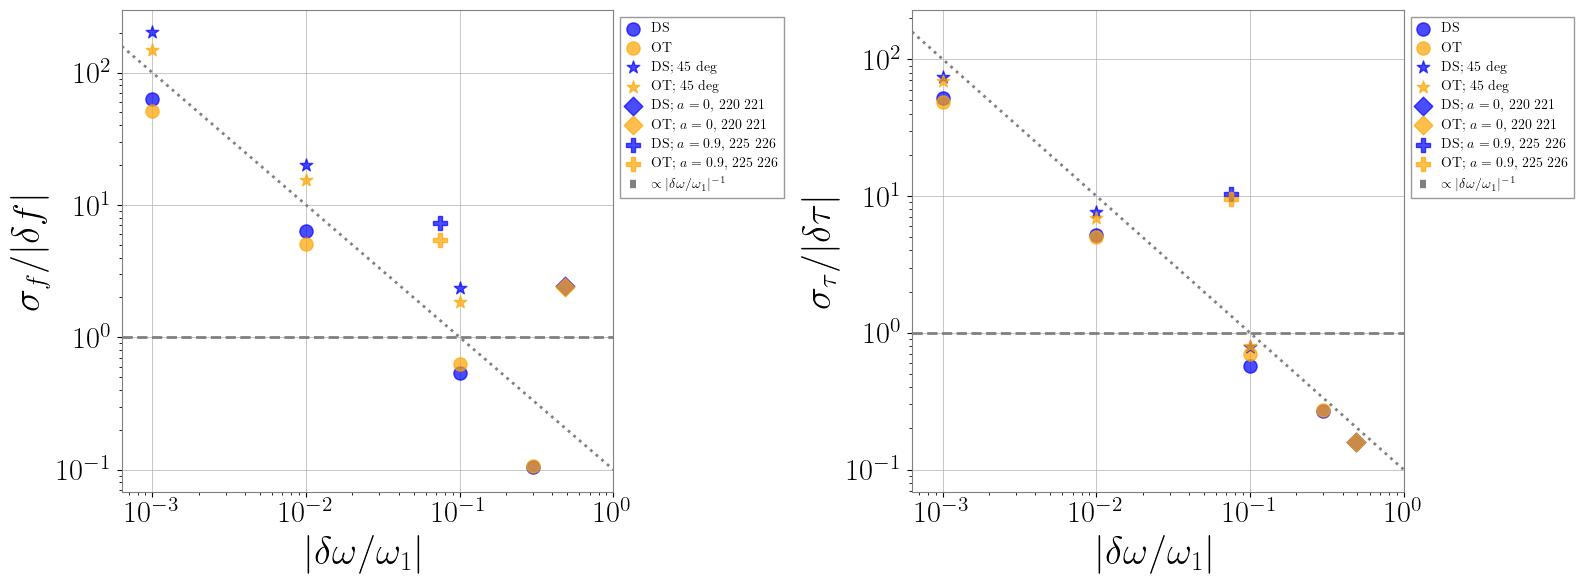

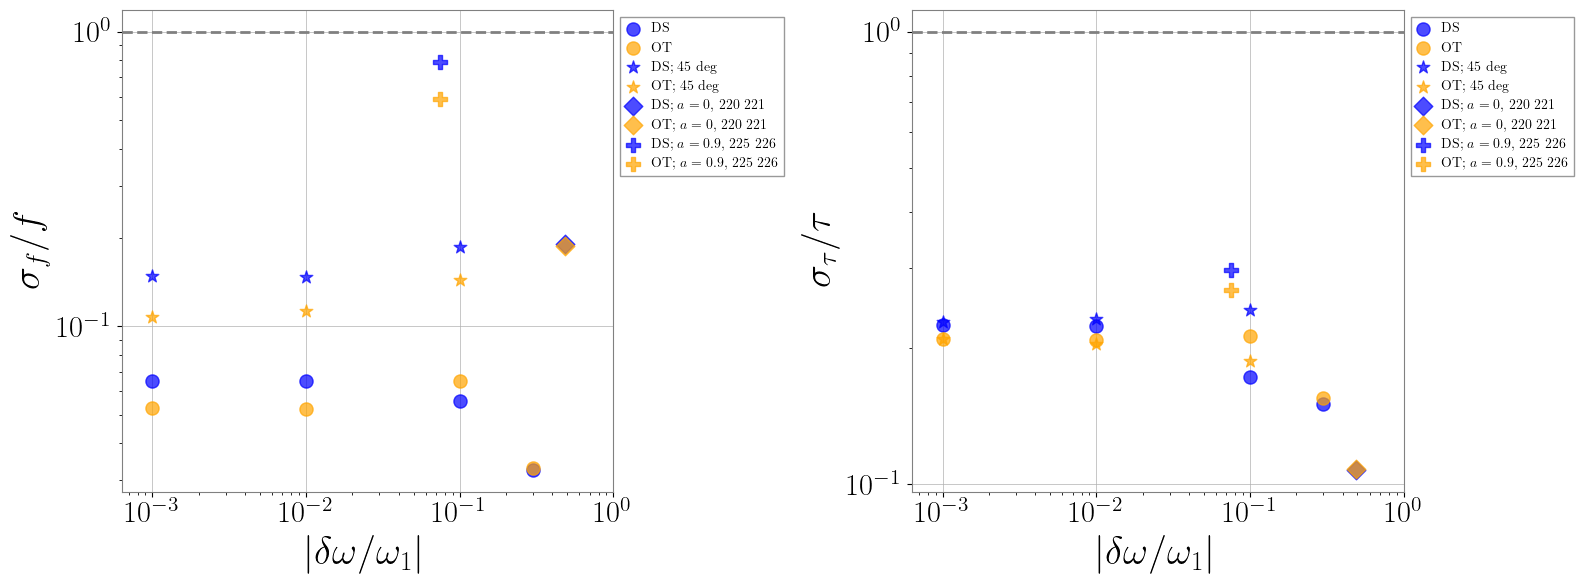

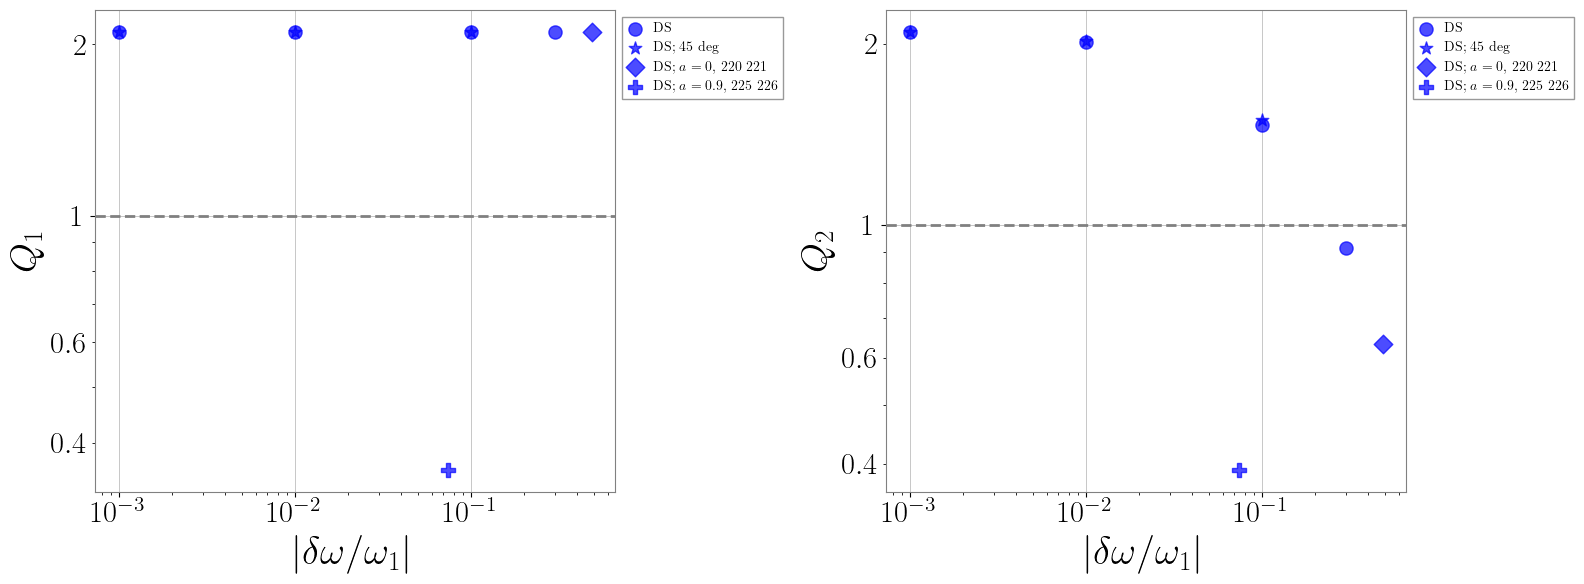

In [27]:
plt.style.use('~/research/my_plot_style.style')
fig_size = (16, 6)
marker_size = 90
marker_alpha = 0.7
fontsize_legend = 10
bbox_to_anchor = (1, 1)
loc_legend = 'upper left'
plot_min = 10**(-3.2) 
plot_max = 10**(0)

"""plot resolvability in frequency and time"""
fig, ax = plt.subplots(1, 2, figsize=fig_size)

DS_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_resolv_f_pyring = [r['resolvability_f'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_resolv_tau_pyring = [r['resolvability_tau'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_dw_over_w1_pyring, DS_resolv_f_pyring, marker='o', color='blue', label='DS', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_dw_over_w1_pyring, DS_resolv_tau_pyring, marker='o', color='blue', label='DS', s=marker_size, alpha=marker_alpha)

OT_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_resolv_f_pyring = [r['resolvability_f'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_resolv_tau_pyring = [r['resolvability_tau'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_dw_over_w1_pyring, OT_resolv_f_pyring, marker='o', color='orange', label='OT', s=marker_size, alpha=marker_alpha)
ax[1].scatter(OT_dw_over_w1_pyring, OT_resolv_tau_pyring, marker='o', color='orange', label='OT', s=marker_size, alpha=marker_alpha)

DS_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_resolv_f_pyring = [r['resolvability_f'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_resolv_tau_pyring = [r['resolvability_tau'] for r in DS_45deg_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_resolv_f_pyring, marker='*', color='blue', label='DS; 45 deg', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_resolv_tau_pyring, marker='*', color='blue', label='DS; 45 deg', s=marker_size, alpha=marker_alpha)

OT_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_resolv_f_pyring = [r['resolvability_f'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_resolv_tau_pyring = [r['resolvability_tau'] for r in OT_45deg_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_resolv_f_pyring, marker='*', color='orange', label=r'OT; 45 deg', s=marker_size, alpha=marker_alpha)
ax[1].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_resolv_tau_pyring, marker='*', color='orange', label=r'OT; 45 deg', s=marker_size, alpha=marker_alpha)

DS_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_220_221_result_list_pyring if r['resolvability_f'] is not None]
DS_220_221_resolv_f_pyring = [r['resolvability_f'] for r in DS_220_221_result_list_pyring if r['resolvability_f'] is not None]
DS_220_221_resolv_tau_pyring = [r['resolvability_tau'] for r in DS_220_221_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_220_221_dw_over_w1_pyring, DS_220_221_resolv_f_pyring, marker='D', color='blue', label=r'DS; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_220_221_dw_over_w1_pyring, DS_220_221_resolv_tau_pyring, marker='D', color='blue', label=r'DS; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)

OT_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_220_221_result_list_pyring if r['resolvability_f'] is not None]
OT_220_221_resolv_f_pyring = [r['resolvability_f'] for r in OT_220_221_result_list_pyring if r['resolvability_f'] is not None]
OT_220_221_resolv_tau_pyring = [r['resolvability_tau'] for r in OT_220_221_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_220_221_dw_over_w1_pyring, OT_220_221_resolv_f_pyring, marker='D', color='orange', label=r'OT; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)
ax[1].scatter(OT_220_221_dw_over_w1_pyring, OT_220_221_resolv_tau_pyring, marker='D', color='orange', label=r'OT; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)

DS_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
DS_kerr_225_226_resolv_f_pyring = [r['resolvability_f'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
DS_kerr_225_226_resolv_tau_pyring = [r['resolvability_tau'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_kerr_225_226_dw_over_w1_pyring, DS_kerr_225_226_resolv_f_pyring, marker='P', color='blue', label=r'DS; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_kerr_225_226_dw_over_w1_pyring, DS_kerr_225_226_resolv_tau_pyring, marker='P', color='blue', label=r'DS; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)

OT_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
OT_kerr_225_226_resolv_f_pyring = [r['resolvability_f'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
OT_kerr_225_226_resolv_tau_pyring = [r['resolvability_tau'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_kerr_225_226_dw_over_w1_pyring, OT_kerr_225_226_resolv_f_pyring, marker='P', color='orange', label=r'OT; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)
ax[1].scatter(OT_kerr_225_226_dw_over_w1_pyring, OT_kerr_225_226_resolv_tau_pyring, marker='P', color='orange', label=r'OT; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)

x_array = np.linspace(plot_min, plot_max, 100)
ax[0].plot(x_array, 1/x_array * 1e-1, color='gray', linestyle=':', label=r'$\propto |\delta\omega / \omega_{1}|^{-1}$')
ax[1].plot(x_array, 1/x_array * 1e-1, color='gray', linestyle=':', label=r'$\propto |\delta\omega / \omega_{1}|^{-1}$')

ax[0].axhline(y=1, color='gray', linestyle='--')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0].set_ylabel(r'$\sigma_{f} / |\delta f|$')
ax[0].set_xlim(plot_min, plot_max)
ax[0].legend(bbox_to_anchor=bbox_to_anchor, loc=loc_legend, fontsize=fontsize_legend)
ax[0].grid(True)

ax[1].axhline(y=1, color='gray', linestyle='--')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1].set_ylabel(r'$\sigma_{\tau} / |\delta \tau|$')
ax[1].set_xlim(plot_min, plot_max)
ax[1].legend(bbox_to_anchor=bbox_to_anchor, loc=loc_legend, fontsize=fontsize_legend)
ax[1].grid(True)

for _ax in ax.flatten():
    _ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

"""plot delta_f and delta_tau vs dw/w1"""
fig, ax = plt.subplots(1, 2, figsize=fig_size)

DS_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_sigma_f_pyring = [r['sigma_f_over_f'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_sigma_tau_pyring = [r['sigma_tau_over_tau'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_dw_over_w1_pyring, DS_sigma_f_pyring, marker='o', color='blue', label='DS', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_dw_over_w1_pyring, DS_sigma_tau_pyring, marker='o', color='blue', label='DS', s=marker_size, alpha=marker_alpha)

OT_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_sigma_f_pyring = [r['sigma_f_over_f'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_sigma_tau_pyring = [r['sigma_tau_over_tau'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_dw_over_w1_pyring, OT_sigma_f_pyring, marker='o', color='orange', label='OT', s=marker_size, alpha=marker_alpha)
ax[1].scatter(OT_dw_over_w1_pyring, OT_sigma_tau_pyring, marker='o', color='orange', label='OT', s=marker_size, alpha=marker_alpha)

DS_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_sigma_f_pyring = [r['sigma_f_over_f'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_sigma_tau_pyring = [r['sigma_tau_over_tau'] for r in DS_45deg_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_sigma_f_pyring, marker='*', color='blue', label='DS; 45 deg', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_sigma_tau_pyring, marker='*', color='blue', label='DS; 45 deg', s=marker_size, alpha=marker_alpha)

OT_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_sigma_f_pyring = [r['sigma_f_over_f'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_sigma_tau_pyring = [r['sigma_tau_over_tau'] for r in OT_45deg_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_sigma_f_pyring, marker='*', color='orange', label=r'OT; 45 deg', s=marker_size, alpha=marker_alpha)
ax[1].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_sigma_tau_pyring, marker='*', color='orange', label=r'OT; 45 deg', s=marker_size, alpha=marker_alpha)

DS_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_220_221_result_list_pyring if r['resolvability_f'] is not None]
DS_220_221_sigma_f_pyring = [r['sigma_f_over_f'] for r in DS_220_221_result_list_pyring if r['resolvability_f'] is not None]
DS_220_221_sigma_tau_pyring = [r['sigma_tau_over_tau'] for r in DS_220_221_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_220_221_dw_over_w1_pyring, DS_220_221_sigma_f_pyring, marker='D', color='blue', label=r'DS; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_220_221_dw_over_w1_pyring, DS_220_221_sigma_tau_pyring, marker='D', color='blue', label=r'DS; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)

OT_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_220_221_result_list_pyring if r['resolvability_f'] is not None]
OT_220_221_sigma_f_pyring = [r['sigma_f_over_f'] for r in OT_220_221_result_list_pyring if r['resolvability_f'] is not None]
OT_220_221_sigma_tau_pyring = [r['sigma_tau_over_tau'] for r in OT_220_221_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_220_221_dw_over_w1_pyring, OT_220_221_sigma_f_pyring, marker='D', color='orange', label=r'OT; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)
ax[1].scatter(OT_220_221_dw_over_w1_pyring, OT_220_221_sigma_tau_pyring, marker='D', color='orange', label=r'OT; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)

DS_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
DS_kerr_225_226_sigma_f_pyring = [r['sigma_f_over_f'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
DS_kerr_225_226_sigma_tau_pyring = [r['sigma_tau_over_tau'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_kerr_225_226_dw_over_w1_pyring, DS_kerr_225_226_sigma_f_pyring, marker='P', color='blue', label=r'DS; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_kerr_225_226_dw_over_w1_pyring, DS_kerr_225_226_sigma_tau_pyring, marker='P', color='blue', label=r'DS; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)

OT_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
OT_kerr_225_226_sigma_f_pyring = [r['sigma_f_over_f'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
OT_kerr_225_226_sigma_tau_pyring = [r['sigma_tau_over_tau'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_kerr_225_226_dw_over_w1_pyring, OT_kerr_225_226_sigma_f_pyring, marker='P', color='orange', label=r'OT; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)
ax[1].scatter(OT_kerr_225_226_dw_over_w1_pyring, OT_kerr_225_226_sigma_tau_pyring, marker='P', color='orange', label=r'OT; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)

ax[0].axhline(y=1, color='gray', linestyle='--')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0].set_ylabel(r'$\sigma_{f}/f$')
ax[0].set_xlim(plot_min, plot_max)
ax[0].legend(bbox_to_anchor=bbox_to_anchor, loc=loc_legend, fontsize=fontsize_legend)
ax[0].grid(True)

ax[1].axhline(y=1, color='gray', linestyle='--')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1].set_ylabel(r'$\sigma_{\tau}/\tau$')
ax[1].set_xlim(plot_min, plot_max)
ax[1].legend(bbox_to_anchor=bbox_to_anchor, loc=loc_legend, fontsize=fontsize_legend)
ax[1].grid(True)

for _ax in ax.flatten():
    _ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

"""plot Q1 and Q2"""
fig, ax = plt.subplots(1, 2, figsize=fig_size)

DS_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_Q1_pyring = [r['Q1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_Q2_pyring = [r['Q2'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_dw_over_w1_pyring, DS_Q1_pyring, marker='o', color='blue', label='DS', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_dw_over_w1_pyring, DS_Q2_pyring, marker='o', color='blue', label='DS', s=marker_size, alpha=marker_alpha)

# OT_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
# OT_Q1_pyring = [r['Q1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
# OT_Q2_pyring = [r['Q2'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
# ax[0].scatter(OT_dw_over_w1_pyring, OT_Q1_pyring, marker='o', color='orange', label='OT', s=marker_size, alpha=marker_alpha)
# ax[1].scatter(OT_dw_over_w1_pyring, OT_Q2_pyring, marker='o', color='orange', label='OT', s=marker_size, alpha=marker_alpha)

DS_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_Q1_pyring = [r['Q1'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_Q2_pyring = [r['Q2'] for r in DS_45deg_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_Q1_pyring, marker='*', color='blue', label='DS; 45 deg', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_Q2_pyring, marker='*', color='blue', label='DS; 45 deg', s=marker_size, alpha=marker_alpha)

# OT_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
# OT_45deg_Q1_pyring = [r['Q1'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
# OT_45deg_Q2_pyring = [r['Q2'] for r in OT_45deg_result_list_pyring if r['resolvability_tau'] is not None]
# ax[0].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_Q1_pyring, marker='*', color='orange', label=r'OT; 45 deg', s=marker_size, alpha=marker_alpha)
# ax[1].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_Q2_pyring, marker='*', color='orange', label=r'OT; 45 deg', s=marker_size, alpha=marker_alpha)

DS_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_220_221_result_list_pyring if r['resolvability_f'] is not None]
DS_220_221_Q1_pyring = [r['Q1'] for r in DS_220_221_result_list_pyring if r['resolvability_f'] is not None]
DS_220_221_Q2_pyring = [r['Q2'] for r in DS_220_221_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_220_221_dw_over_w1_pyring, DS_220_221_Q1_pyring, marker='D', color='blue', label=r'DS; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_220_221_dw_over_w1_pyring, DS_220_221_Q2_pyring, marker='D', color='blue', label=r'DS; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)

# OT_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_220_221_result_list_pyring if r['resolvability_f'] is not None]
# OT_220_221_Q1_pyring = [r['Q1'] for r in OT_220_221_result_list_pyring if r['resolvability_f'] is not None]
# OT_220_221_Q2_pyring = [r['Q2'] for r in OT_220_221_result_list_pyring if r['resolvability_tau'] is not None]
# ax[0].scatter(OT_220_221_dw_over_w1_pyring, OT_220_221_Q1_pyring, marker='D', color='orange', label=r'OT; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)
# ax[1].scatter(OT_220_221_dw_over_w1_pyring, OT_220_221_Q2_pyring, marker='D', color='orange', label=r'OT; $a=0$, 220 221', s=marker_size, alpha=marker_alpha)

DS_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
DS_kerr_225_226_Q1_pyring = [r['Q1'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
DS_kerr_225_226_Q2_pyring = [r['Q2'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_kerr_225_226_dw_over_w1_pyring, DS_kerr_225_226_Q1_pyring, marker='P', color='blue', label=r'DS; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_kerr_225_226_dw_over_w1_pyring, DS_kerr_225_226_Q2_pyring, marker='P', color='blue', label=r'DS; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)

# OT_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
# OT_kerr_225_226_Q1_pyring = [r['Q1'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
# OT_kerr_225_226_Q2_pyring = [r['Q2'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_tau'] is not None]
# ax[0].scatter(OT_kerr_225_226_dw_over_w1_pyring, OT_kerr_225_226_Q1_pyring, marker='P', color='orange', label=r'OT; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)
# ax[1].scatter(OT_kerr_225_226_dw_over_w1_pyring, OT_kerr_225_226_Q2_pyring, marker='P', color='orange', label=r'OT; $a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)

ax[0].axhline(y=1, color='gray', linestyle='--')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0].set_ylabel(r'$Q_1$')
ax[0].legend(bbox_to_anchor=bbox_to_anchor, loc=loc_legend, fontsize=fontsize_legend)
ax[0].grid(True)

ax[1].axhline(y=1, color='gray', linestyle='--')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1].set_ylabel(r'$Q_2$')
ax[1].legend(bbox_to_anchor=bbox_to_anchor, loc=loc_legend, fontsize=fontsize_legend)
ax[1].grid(True)

for _ax in ax.flatten():
    _ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

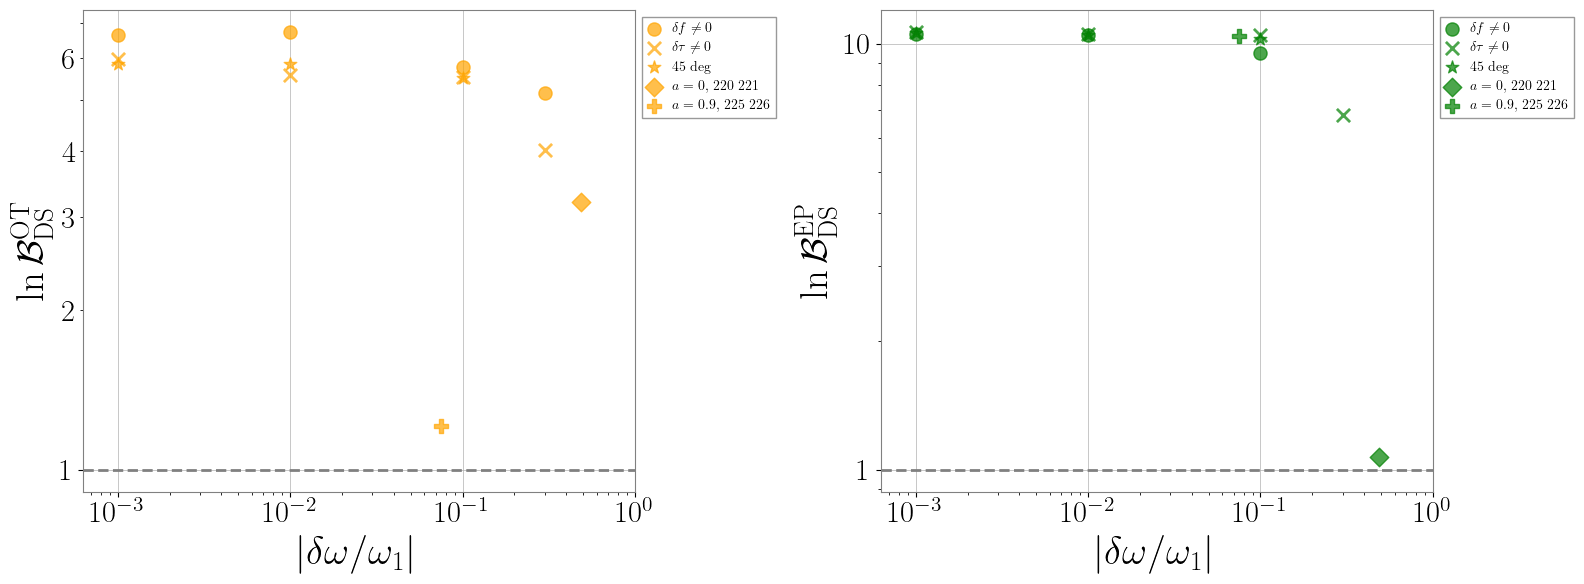

In [33]:
plt.style.use('~/research/my_plot_style.style')
fig_size = (16, 6)
marker_size = 90
marker_alpha = 0.7
fontsize_legend = 10
bbox_to_anchor = (1, 1)
loc_legend = 'upper left'
plot_min = 10**(-3.2) 
plot_max = 10**(0)

"""plot resolvability in frequency and time"""
fig, ax = plt.subplots(1, 2, figsize=fig_size)

DS_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_lnB_shiftRe_pyring = [r['lnB'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_lnB_shiftIm_pyring = [r['lnB'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
OT_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_lnB_shiftRe_pyring = [r['lnB'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_lnB_shiftIm_pyring = [r['lnB'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
EP_dw_over_w1_pyring = [r['dw_over_w1'] for r in EP_result_list_pyring if r['resolvability_f'] is not None]
EP_lnB_shiftRe_pyring = [r['lnB'] for r in EP_result_list_pyring if r['resolvability_f'] is not None]
EP_lnB_shiftIm_pyring = [r['lnB'] for r in EP_result_list_pyring if r['resolvability_tau'] is not None]

lnB_shiftRe_OT_DS = np.array(OT_lnB_shiftRe_pyring) - np.array(DS_lnB_shiftRe_pyring)
lnB_shiftRe_EP_DS = np.array(EP_lnB_shiftRe_pyring) - np.array(DS_lnB_shiftRe_pyring)
lnB_shiftIm_OT_DS = np.array(OT_lnB_shiftIm_pyring) - np.array(DS_lnB_shiftIm_pyring)
lnB_shiftIm_EP_DS = np.array(EP_lnB_shiftIm_pyring) - np.array(DS_lnB_shiftIm_pyring)
ax[0].scatter(DS_dw_over_w1_pyring, lnB_shiftRe_OT_DS, marker='o', color='orange', label=r'$\delta f\ne0$', s=marker_size, alpha=marker_alpha)
ax[0].scatter(DS_dw_over_w1_pyring, lnB_shiftIm_OT_DS, marker='x', color='orange', label=r'$\delta \tau\ne0$', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_dw_over_w1_pyring, lnB_shiftRe_EP_DS, marker='o', color='green', label=r'$\delta f\ne0$', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_dw_over_w1_pyring, lnB_shiftIm_EP_DS, marker='x', color='green', label=r'$\delta \tau\ne0$', s=marker_size, alpha=marker_alpha)

DS_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_lnB_pyring = [r['lnB'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_lnB_pyring = [r['lnB'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
EP_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in EP_45deg_result_list_pyring if r['resolvability_f'] is not None]
EP_45deg_lnB_pyring = [r['lnB'] for r in EP_45deg_result_list_pyring if r['resolvability_f'] is not None]

lnB_45deg_OT_DS = np.array(OT_45deg_lnB_pyring) - np.array(DS_45deg_lnB_pyring)
lnB_45deg_EP_DS = np.array(EP_45deg_lnB_pyring) - np.array(DS_45deg_lnB_pyring)
ax[0].scatter(DS_45deg_dw_over_w1_pyring, lnB_45deg_OT_DS, marker='*', color='orange', label=r'45 deg', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_45deg_dw_over_w1_pyring, lnB_45deg_EP_DS, marker='*', color='green', label=r'45 deg', s=marker_size, alpha=marker_alpha)

DS_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_220_221_result_list_pyring if r['resolvability_f'] is not None]
DS_220_221_lnB_pyring = [r['lnB'] for r in DS_220_221_result_list_pyring if r['resolvability_f'] is not None]
OT_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_220_221_result_list_pyring if r['resolvability_f'] is not None]
OT_220_221_lnB_pyring = [r['lnB'] for r in OT_220_221_result_list_pyring if r['resolvability_f'] is not None]
EP_220_221_dw_over_w1_pyring = [r['dw_over_w1'] for r in EP_220_221_result_list_pyring if r['resolvability_f'] is not None]
EP_220_221_lnB_pyring = [r['lnB'] for r in EP_220_221_result_list_pyring if r['resolvability_f'] is not None]

lnB_220_221_OT_DS = np.array(OT_220_221_lnB_pyring) - np.array(DS_220_221_lnB_pyring)
lnB_220_221_EP_DS = np.array(EP_220_221_lnB_pyring) - np.array(DS_220_221_lnB_pyring)
ax[0].scatter(DS_220_221_dw_over_w1_pyring, lnB_220_221_OT_DS, marker='D', color='orange', label=r'$a=0$, 220 221', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_220_221_dw_over_w1_pyring, lnB_220_221_EP_DS, marker='D', color='green', label=r'$a=0$, 220 221', s=marker_size, alpha=marker_alpha)


DS_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
DS_kerr_225_226_lnB_pyring = [r['lnB'] for r in DS_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
OT_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
OT_kerr_225_226_lnB_pyring = [r['lnB'] for r in OT_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
EP_kerr_225_226_dw_over_w1_pyring = [r['dw_over_w1'] for r in EP_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]
EP_kerr_225_226_lnB_pyring = [r['lnB'] for r in EP_kerr_225_226_result_list_pyring if r['resolvability_f'] is not None]

lnB_kerr_225_226_OT_DS = np.array(OT_kerr_225_226_lnB_pyring) - np.array(DS_kerr_225_226_lnB_pyring)
lnB_kerr_225_226_EP_DS = np.array(EP_kerr_225_226_lnB_pyring) - np.array(DS_kerr_225_226_lnB_pyring)
ax[0].scatter(DS_kerr_225_226_dw_over_w1_pyring, lnB_kerr_225_226_OT_DS, marker='P', color='orange', label=r'$a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)
ax[1].scatter(DS_kerr_225_226_dw_over_w1_pyring, lnB_kerr_225_226_EP_DS, marker='P', color='green', label=r'$a=0.9$, 225 226', s=marker_size, alpha=marker_alpha)

ax[0].axhline(y=1, color='gray', linestyle='--')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0].set_ylabel(r'$\ln \mathcal{B}^{\mathrm{OT}}_{\mathrm{DS}}$')
ax[0].set_xlim(plot_min, plot_max)
ax[0].legend(bbox_to_anchor=bbox_to_anchor, loc=loc_legend, fontsize=fontsize_legend)
ax[0].grid(True)

ax[1].axhline(y=1, color='gray', linestyle='--')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1].set_ylabel(r'$\ln \mathcal{B}^{\mathrm{EP}}_{\mathrm{DS}}$')
ax[1].set_xlim(plot_min, plot_max)
ax[1].legend(bbox_to_anchor=bbox_to_anchor, loc=loc_legend, fontsize=fontsize_legend)
ax[1].grid(True)

for _ax in ax.flatten():
    _ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

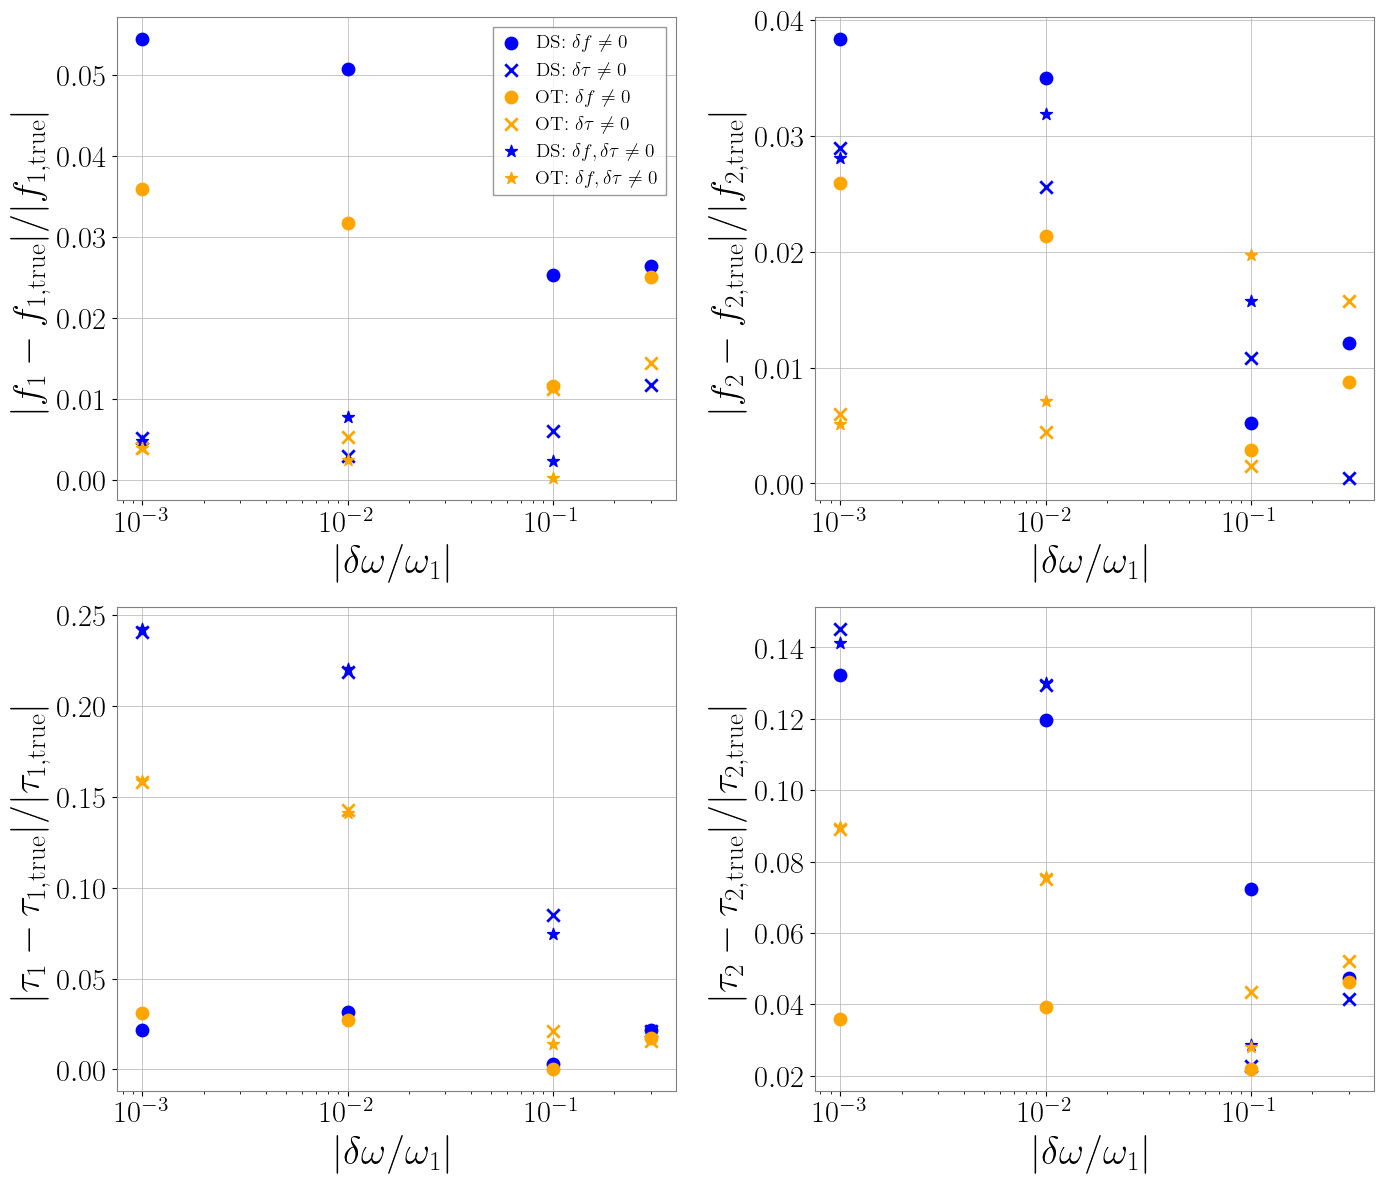

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

# DS_Mirror_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# DS_Mirror_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# DS_Mirror_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# DS_Mirror_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[0, 0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[0, 1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[0, 1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[1, 0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[1, 0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[1, 1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[1, 1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')

# DS_Heaviside_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# DS_Heaviside_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# DS_Heaviside_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# DS_Heaviside_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[0, 0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[0, 1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[0, 1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[1, 0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[1, 0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[1, 1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[1, 1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')

# OT_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in OT_result_list if r['resolvability_tau'] is not None]
# OT_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in OT_result_list if r['resolvability_tau'] is not None]
# OT_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in OT_result_list if r['resolvability_tau'] is not None]
# OT_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in OT_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(OT_dw_over_w1, OT_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# ax[0, 0].scatter(OT_dw_over_w1, OT_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
# ax[0, 1].scatter(OT_dw_over_w1, OT_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# ax[0, 1].scatter(OT_dw_over_w1, OT_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
# ax[1, 0].scatter(OT_dw_over_w1, OT_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# ax[1, 0].scatter(OT_dw_over_w1, OT_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
# ax[1, 1].scatter(OT_dw_over_w1, OT_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# ax[1, 1].scatter(OT_dw_over_w1, OT_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')

# OT_conditional_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# OT_conditional_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# OT_conditional_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# OT_conditional_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[0, 0].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[0, 1].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[0, 1].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[1, 0].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[1, 0].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[1, 1].scatter(OT_dw_over_w1, OT_condditional_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[1, 1].scatter(OT_dw_over_w1, OT_condditional_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')

# OTRA_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# OTRA_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# OTRA_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# OTRA_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# ax[0, 0].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')
# ax[0, 1].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# ax[0, 1].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')
# ax[1, 0].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# ax[1, 0].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')
# ax[1, 1].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# ax[1, 1].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')

# OTRA_delta_prior_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_prior_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# OTRA_delta_prior_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_prior_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# OTRA_delta_f_prior_resolv_factional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_tau_prior_resolv_factional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# OTRA_delta_f_prior_resolv_factional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_tau_prior_resolv_factional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(OT_dw_over_w1, OTRA_delta_prior_factional_accuracy_f1_shiftRe, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[0, 0].scatter(OT_dw_over_w1, OTRA_delta_prior_factional_accuracy_f1_shiftIm, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[0, 1].scatter(OT_dw_over_w1, OTRA_delta_prior_factional_accuracy_f2_shiftRe, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[0, 1].scatter(OT_dw_over_w1, OTRA_delta_prior_factional_accuracy_f2_shiftIm, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[1, 0].scatter(OT_dw_over_w1, OTRA_delta_f_prior_resolv_factional_accuracy_tau1_shiftRe, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[1, 0].scatter(OT_dw_over_w1, OTRA_delta_tau_prior_resolv_factional_accuracy_tau1_shiftIm, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[1, 1].scatter(OT_dw_over_w1, OTRA_delta_f_prior_resolv_factional_accuracy_tau2_shiftRe, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[1, 1].scatter(OT_dw_over_w1, OTRA_delta_tau_prior_resolv_factional_accuracy_tau2_shiftIm, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')

DS_fractional_accuracy_f1_shiftRe_pyring = [r['fractional_accuracy_f1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_f1_shiftIm_pyring = [r['fractional_accuracy_f1'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
DS_fractional_accuracy_f2_shiftRe_pyring = [r['fractional_accuracy_f2'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_f2_shiftIm_pyring = [r['fractional_accuracy_f2'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
DS_fractional_accuracy_tau1_shiftRe_pyring = [r['fractional_accuracy_tau1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_tau1_shiftIm_pyring = [r['fractional_accuracy_tau1'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
DS_fractional_accuracy_tau2_shiftRe_pyring = [r['fractional_accuracy_tau2'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_tau2_shiftIm_pyring = [r['fractional_accuracy_tau2'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
ax[0, 0].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_f1_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
ax[0, 0].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_f1_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')
ax[0, 1].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_f2_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
ax[0, 1].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_f2_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')
ax[1, 0].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_tau1_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
ax[1, 0].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_tau1_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')
ax[1, 1].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_tau2_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
ax[1, 1].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_tau2_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')

OT_fractional_accuracy_f1_shiftRe_pyring = [r['fractional_accuracy_f1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_f1_shiftIm_pyring = [r['fractional_accuracy_f1'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
OT_fractional_accuracy_f2_shiftRe_pyring = [r['fractional_accuracy_f2'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_f2_shiftIm_pyring = [r['fractional_accuracy_f2'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
OT_fractional_accuracy_tau1_shiftRe_pyring = [r['fractional_accuracy_tau1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_tau1_shiftIm_pyring = [r['fractional_accuracy_tau1'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
OT_fractional_accuracy_tau2_shiftRe_pyring = [r['fractional_accuracy_tau2'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_tau2_shiftIm_pyring = [r['fractional_accuracy_tau2'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
ax[0, 0].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_f1_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
ax[0, 0].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_f1_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
ax[0, 1].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_f2_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
ax[0, 1].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_f2_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
ax[1, 0].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_tau1_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
ax[1, 0].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_tau1_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
ax[1, 1].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_tau2_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
ax[1, 1].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_tau2_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')

DS_45deg_fractional_accuracy_f1 = [r['fractional_accuracy_f1'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_fractional_accuracy_f2 = [r['fractional_accuracy_f2'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_fractional_accuracy_tau1 = [r['fractional_accuracy_tau1'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_fractional_accuracy_tau2 = [r['fractional_accuracy_tau2'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
ax[0, 0].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_fractional_accuracy_f1, marker='*', s=80, color='blue', label='DS: '+r'$\delta f, \delta\tau\ne 0$')
ax[0, 1].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_fractional_accuracy_f2, marker='*', s=80, color='blue', label='DS: '+r'$\delta f, \delta\tau\ne 0$')
ax[1, 0].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_fractional_accuracy_tau1, marker='*', s=80, color='blue', label='DS: '+r'$\delta f, \delta\tau\ne 0$')
ax[1, 1].scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_fractional_accuracy_tau2, marker='*', s=80, color='blue', label='DS: '+r'$\delta f, \delta\tau\ne 0$')

OT_45deg_fractional_accuracy_f1 = [r['fractional_accuracy_f1'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_fractional_accuracy_f2 = [r['fractional_accuracy_f2'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_fractional_accuracy_tau1 = [r['fractional_accuracy_tau1'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_fractional_accuracy_tau2 = [r['fractional_accuracy_tau2'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
ax[0, 0].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_fractional_accuracy_f1, marker='*', s=80, color='orange', label='OT: '+r'$\delta f, \delta\tau\ne 0$')
ax[0, 1].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_fractional_accuracy_f2, marker='*', s=80, color='orange', label='OT: '+r'$\delta f, \delta\tau\ne 0$')
ax[1, 0].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_fractional_accuracy_tau1, marker='*', s=80, color='orange', label='OT: '+r'$\delta f, \delta\tau\ne 0$')
ax[1, 1].scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_fractional_accuracy_tau2, marker='*', s=80, color='orange', label='OT: '+r'$\delta f, \delta\tau\ne 0$')

ax[0, 0].set_xscale('log')
# ax[0, 0].set_yscale('log')
ax[0, 0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0, 0].set_ylabel(r'$|f_{1} - f_{1, \mathrm{true}}| / |f_{1, \mathrm{true}}|$')
ax[0, 0].legend(fontsize=14)
ax[0, 0].grid(True)

ax[0, 1].set_xscale('log')
# ax[0, 1].set_yscale('log')
ax[0, 1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0, 1].set_ylabel(r'$|f_{2} - f_{2, \mathrm{true}}| / |f_{2, \mathrm{true}}|$')
# ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].set_xscale('log')
# ax[1, 0].set_yscale('log')
ax[1, 0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1, 0].set_ylabel(r'$|\tau_{1} - \tau_{1, \mathrm{true}}| / |\tau_{1, \mathrm{true}}|$')
# ax[1, 0].legend(fontsize=10)
ax[1, 0].grid(True)

ax[1, 1].set_xscale('log')
# ax[1, 1].set_yscale('log')
ax[1, 1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1, 1].set_ylabel(r'$|\tau_{2} - \tau_{2, \mathrm{true}}| / |\tau_{2, \mathrm{true}}|$')
# ax[1, 1].legend()
ax[1, 1].grid(True)

for _ax in ax.flatten():
    _ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

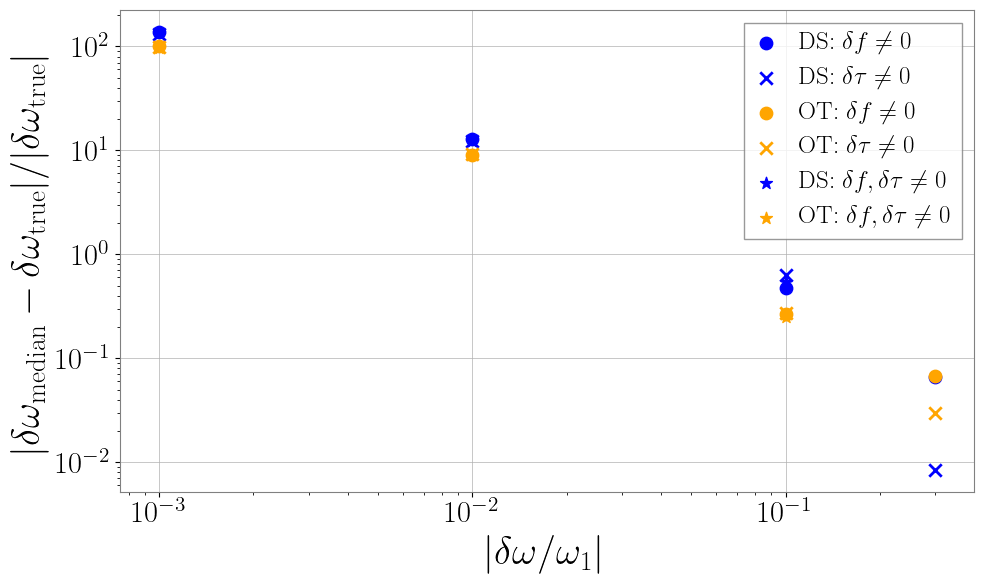

In [15]:
plt.figure()

# DS_Mirror_dw_over_w1 = [r['dw_over_w1'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_dw_shiftRe = [r['fractional_accuracy_dw'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_dw_shiftIm = [r['fractional_accuracy_dw'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# plt.scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_dw_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# plt.scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_dw_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')

# DS_Heaviside_dw_over_w1 = [r['dw_over_w1'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_dw_shiftRe = [r['fractional_accuracy_dw'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_dw_shiftIm = [r['fractional_accuracy_dw'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# plt.scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_dw_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# plt.scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_dw_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')

# OT_dw_over_w1 = [r['dw_over_w1'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_dw_shiftRe = [r['fractional_accuracy_dw'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_dw_shiftIm = [r['fractional_accuracy_dw'] for r in OT_result_list if r['resolvability_tau'] is not None]
# plt.scatter(OT_dw_over_w1, OT_fractional_accuracy_dw_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# plt.scatter(OT_dw_over_w1, OT_fractional_accuracy_dw_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')

# OT_conditional_fractional_accuracy_f = [r['fractional_accuracy_dw'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_tau = [r['fractional_accuracy_dw'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# plt.scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# plt.scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_tau, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')

# OTRA_fractional_accuracy_dw_shiftRe = [r['fractional_accuracy_dw'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_dw_shiftIm = [r['fractional_accuracy_dw'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# plt.scatter(OT_dw_over_w1, OTRA_fractional_accuracy_dw_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# plt.scatter(OT_dw_over_w1, OTRA_fractional_accuracy_dw_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')

# OTRA_conditional_fractional_accuracy_f =[r['fractional_accuracy_dw'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_conditional_fractional_accuracy_tau = [r['fractional_accuracy_dw'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# plt.scatter(OT_dw_over_w1, OTRA_conditional_fractional_accuracy_f, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# plt.scatter(OT_dw_over_w1, OTRA_conditional_fractional_accuracy_tau, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')

DS_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_dw_shiftRe_pyring = [r['fractional_accuracy_dw'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_dw_shiftIm_pyring = [r['fractional_accuracy_dw'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
plt.scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_dw_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
plt.scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_dw_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')

OT_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_dw_shiftRe_pyring = [r['fractional_accuracy_dw'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_dw_shiftIm_pyring = [r['fractional_accuracy_dw'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
plt.scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_dw_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
plt.scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_dw_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')

DS_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
DS_45deg_fractional_accuracy_dw = [r['fractional_accuracy_dw'] for r in DS_45deg_result_list_pyring if r['resolvability_f'] is not None]
plt.scatter(DS_45deg_dw_over_w1_pyring, DS_45deg_fractional_accuracy_dw, marker='*', s=80, color='blue', label='DS: '+r'$\delta f, \delta\tau\ne 0$')

OT_45deg_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
OT_45deg_fractional_accuracy_dw = [r['fractional_accuracy_dw'] for r in OT_45deg_result_list_pyring if r['resolvability_f'] is not None]
plt.scatter(OT_45deg_dw_over_w1_pyring, OT_45deg_fractional_accuracy_dw, marker='*', s=80, color='orange', label='OT: '+r'$\delta f, \delta\tau\ne 0$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$|\delta\omega / \omega_{1}|$')
plt.ylabel(r'$|\delta \omega_{\mathrm{median}} - \delta \omega_{\mathrm{true}}| / |\delta \omega_{\mathrm{true}}|$')
plt.legend()
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()